In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import *
from sklearn.model_selection import GridSearchCV, cross_validate
from sklearn.ensemble import *
from sklearn.pipeline import Pipeline
from category_encoders import TargetEncoder

In [43]:
data_model = pd.read_csv('data/data_model.csv')
print(data_model.shape)
data_model.head()

(750000, 26)


,id,age,job,education,default,balance,housing,loan,day,month,...,marital_married,marital_single,contact_cellular,contact_telephone,contact_unknown_contact,poutcome_failure,poutcome_other,poutcome_success,poutcome_unknown_poutcome,job_target_mean
0,0,42,technician,2,0,7,0,0,25,8,...,1,0,1,0,0,0,0,0,1,0.118321
1,1,38,blue-collar,2,0,514,0,0,18,6,...,1,0,0,0,1,0,0,0,1,0.067438
2,2,36,blue-collar,2,0,602,1,0,14,5,...,1,0,0,0,1,0,0,0,1,0.067438
3,3,27,student,2,0,34,1,0,28,5,...,0,1,0,0,1,0,0,0,1,0.340784
4,4,26,technician,2,0,889,1,0,3,2,...,1,0,1,0,0,0,0,0,1,0.118321


## split data to train, val, and test

In [44]:
X = data_model.drop(['id','deposit'],axis=1)
y = data_model['deposit']

In [45]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

In [46]:
# pipeline = Pipeline([
#     ('ctg_encoder', TargetEncoder(cols=['job'])),
#     ('clf', RandomForestClassifier(random_state=42))
# ])

ctg_encoder = TargetEncoder(cols=['job'])

X_train['job'] = ctg_encoder.fit_transform(X_train['job'], y_train)
X_test['job'] = ctg_encoder.transform(X_test['job'], y_test)

## Use regular model

## Use cross validation

### use stratifiedkfold for training set only

using this approach is faster (split the data first, then perform gridsearchcv with stratifiedkfold)

In [33]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
# scores = cross_val_score(RandomForestClassifier(random_state=42), X_train, y_train, cv=cv, scoring='precision')
# print("Mean CV Accuracy:", scores.mean())

In [58]:
def bestRFClassifier(X, y):
    param_grid = {
        'max_depth': [3, 4, 5, 6, 7, 8]
    }

    grid_search = GridSearchCV(
        estimator=RandomForestClassifier(random_state=42),
        param_grid=param_grid,
        cv=skf,
        scoring='recall',
        return_train_score=True,
    )

    grid_search.fit(X_train, y_train)

    best_model = grid_search.best_estimator_
    y_pred = best_model.predict(X_test)

    best_test_score_rf = grid_search.score(X_test, y_test)
    best_max_depth = grid_search.best_params_['max_depth']
    best_cv_score_rf = grid_search.best_score_

    return best_test_score_rf, best_max_depth, best_cv_score_rf, best_model, best_model, X_train, y_train, y_test, y_pred

best_test_score_rf, best_max_depth, best_cv_score_rf, best_model, best_model, X_train, y_train, y_test, y_pred = bestRFClassifier(X_train, y_train)


[[130773   1129]
 [ 12730   5368]]
              precision    recall  f1-score   support

           0       0.91      0.99      0.95    131902
           1       0.83      0.30      0.44     18098

    accuracy                           0.91    150000
   macro avg       0.87      0.64      0.69    150000
weighted avg       0.90      0.91      0.89    150000



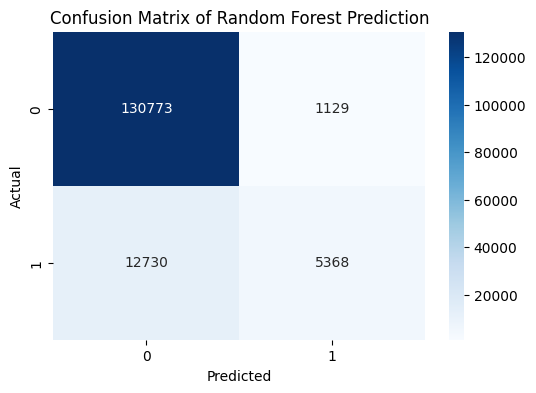

In [31]:
cm = confusion_matrix(y_test, y_pred)
labels = list(data_model['deposit'].unique())
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

# Plot heatmap
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=labels, yticklabels=labels)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix of Random Forest Prediction")
plt.show()

this approach (using skf.split, gridsearch every iteration) is taking way longer

In [56]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)
rf = RandomForestClassifier(random_state=42)
accs, precs, recs = [], [], []
for train_index, test_index in skf.split(X_train, y_train):
    x_train_fold = X_train.iloc[train_index]
    x_test_fold  = X_train.iloc[test_index]
    y_train_fold = y_train.iloc[train_index]
    y_test_fold  = y_train.iloc[test_index]

    param_grid = {
        'max_depth': [3, 4, 5, 6, 7, 8]
    }

    grid_search = GridSearchCV(
        estimator=rf,
        param_grid=param_grid,
        cv=skf,
        scoring='recall',
        return_train_score=True,
    )

    grid_search.fit(x_train_fold, y_train_fold)
    best_model = grid_search.best_estimator_
    y_pred = best_model.predict(x_test_fold)
    
    acc = accuracy_score(y_test_fold, y_pred)
    prec = precision_score(y_test_fold, y_pred)
    rec = recall_score(y_test_fold, y_pred)
    accs.append(acc)
    precs.append(prec)
    recs.append(rec)
    print(f'Accuracy: {acc}, Precision: {prec}, Recall: {rec}')

print(f'Mean Accuracy: {np.mean(accs)}, Mean Precision: {np.mean(precs)}, Mean Recall: {np.mean(recs)}')

Accuracy: 0.90725, Precision: 0.833732057416268, Recall: 0.2888520513883133
Accuracy: 0.9104333333333333, Precision: 0.8279985930355258, Recall: 0.32518303633098494
Accuracy: 0.9090083333333333, Precision: 0.8259754533797399, Recall: 0.31143804392871943
Accuracy: 0.9082916666666667, Precision: 0.8217528256438762, Recall: 0.3063268407238569
Accuracy: 0.9113416666666667, Precision: 0.8201834862385321, Recall: 0.3396187318690427
Mean Accuracy: 0.9092650000000001, Mean Precision: 0.8259284831427884, Mean Recall: 0.31428374084818345


In [57]:
best_model

,n_estimators,100
,criterion,'gini'
,max_depth,8
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False
